## 1D Fiting with SASView from notebook
## cylinder model template notebook

* import all the packages
* install packages before using a separate notebook
* better to work in a dedicated python environnement

In [1]:
import numpy as np

# import sasmodels
import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
#from sas import sascalc.dataloader

from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

* configuration of matplotlib for plots 

In [2]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14) # default fontsize
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

# this one is for 2D SAXS images
plt.rc('image', cmap='jet')

* example of checking the version of a SASView packages

In [ ]:
sasdata.__version__

'0.11.0'

In [ ]:
sasmodels.__version__

'1.0.12'

### Load a 1D data file

* load an experimental data file .dat 
* define here filename and path on your computer

In [3]:
# Form Factor PR32 in the reference rack
# 5 different positions with some noticable concentration gradient
filenameraw = "PR32M_00015{00000}_AzInt_Px_104.dat"
#filenameraw = "PR32M_00015{00001}_AzInt_Px_105.dat"
#filenameraw = "PR32M_00015{00002}_AzInt_Px_106.dat"
#filenameraw = "PR32M_00015{00003}_AzInt_Px_107.dat"
#filenameraw = "PR32M_00015{00004}_AzInt_Px_108.dat"


* subtraction from empty file

In [4]:
fileempty = "Ave_117_water0p05_00011AzInt_Px.dat"

total number of data points:  1213
total empty number of data points:  1213


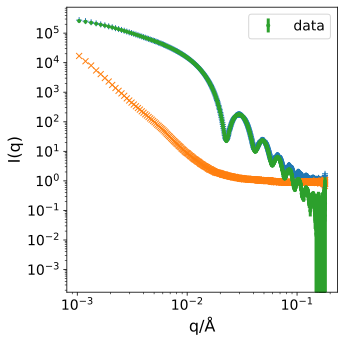

In [14]:
# number of lines in the header
skipheader = 42

# Using loadtxt to load data
data_np = np.loadtxt(filenameraw, skiprows=skipheader)

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# datasub incorporates the subtraction of empty file
coeffempty = 1.
empty_np = np.loadtxt(fileempty, skiprows=skipheader-20)
total_empty_data_number = empty_np.shape[0]
print('total empty number of data points: ', total_empty_data_number)

plt.loglog(empty_np[:,0], coeffempty*empty_np[:,1], 'x')

datasub = sasmodels.data.Data1D(
    x=data_np[0:total_data_number, 0],
    y=data_np[0:total_data_number, 1] - coeffempty*empty_np[0:total_data_number, 1],
    dy=data_np[0:total_data_number, 2])

sasmodels.data.plot_data(datasub)

In [15]:
subfilename = filenameraw[:-4] + '_sub.dat'

with open(subfilename, 'w') as f:
    f.write('raw data file is:' + filenameraw + '\n')
    f.write('number of data points: \t' + str(total_data_number) + '\n')

with open(subfilename, 'a') as fa:
    for i in range(0, total_data_number):
        line_to_write = str(datasub.x[i]) + '\t' + str(datasub.y[i]) + '\t' + str(datasub.dy[i]) + '\n'
        fa.write(line_to_write)

In [16]:
filename = subfilename

Process the data file:
* use `skiheader` to skip the header 
* use `skipmin` to skip data points at low q values
* use `skipmax` to skip data points at large q values
* load the data in a numpy array and show a first plot
* use `slicing_step` to reduce the number of data points (slicing_step=3 means that 1 point over 3 is taken)
* use `rescale` the intensity coefficient for rescaling (in cm-1) if not done previously
* use `coeff` to compute realistic error bars as a percentage of intensity values (coeff=0.1 means 10% of intensity error bars)
* transform the numpy array into a suitable 1D data set using `sasmodels.data.Data1D`
* data plot shows the complete data `data_np` set and the new one `data`

total number of data points:  1211
after skip at low and large q values: 861
after slicing: 287


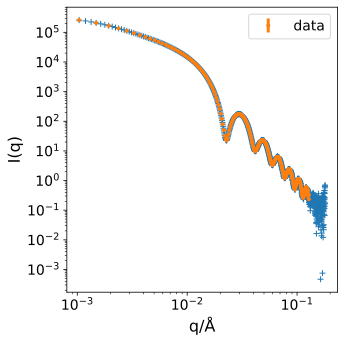

In [17]:
#number of lines in the header
skipheader=4 # 50 for a SWING data set

data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

#number of points to skip at low q values
skipmin=0
data_np = np.loadtxt(filename, skiprows=skipheader+skipmin)

# number of data point to skip at the end
skipmax=350
number_of_data=total_data_number-skipmax-skipmin

print('after skip at low and large q values:', number_of_data)

slicing_step=3 # step of slicing 

# rescaling of intensity values
# rescale=0.036 scaling factor from SWING to be in cm-1 for 1 mm sample thickness
# rescale=0.036/e(mm) scaling factor from SWING to be in cm-1 for e mm sample thickness
# rescale=1 if data are already rescaled using Foxtrot macro
rescale=1

# new error bars: 10 % of intensity values
coeff=0.1

#data = sasmodels.data.Data1D(x=data_np[:,0], y=data_np[:,1], dy=data_np[:,2])
data = sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*data_np[0:number_of_data:slicing_step,1], 
                             dy=rescale*coeff*abs(data_np[0:number_of_data:slicing_step,1]))

number_of_data_new=data.x.shape[0]
print('after slicing:', number_of_data_new)

sasmodels.data.plot_data(data)

* plot of the new data set `data`

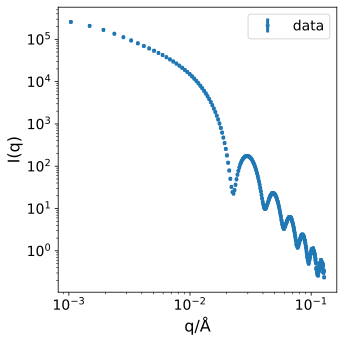

In [18]:
sasmodels.data.plot_data(data)

### save `data` in a new data file
* add `_new`at the end of the name

In [19]:

newfilename=filename[:-4]+"_new.dat" # data 

with open(newfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(newfilename, "a") as fa:
    for i in range(0,number_of_data_new):
        line_to_write=str(data.x[i])+"\t"+str(data.y[i])+"\t"+str(data.dy[i])+"\n"
        fa.write(line_to_write)

### fit the data

* create the computation `kernel` selecting the `cylinder` model
* create the `model` interfaced with bump module
* create the `experiment`, containing both data and model

In [20]:
kernel = sasmodels.core.load_model("cylinder")
params = {} # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

* default values of all parameters

In [21]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'sld': 4,
 'sld_solvent': 1,
 'radius': 20,
 'length': 400,
 'theta': 60,
 'phi': 60,
 'up_frac_i': 0.0,
 'up_frac_f': 0.0,
 'up_theta': 90.0,
 'up_phi': 0.0,
 'sld_M0': 0.0,
 'sld_mtheta': 0.0,
 'sld_mphi': 0.0,
 'sld_solvent_M0': 0.0,
 'sld_solvent_mtheta': 0.0,
 'sld_solvent_mphi': 0.0}

#### preliminary step: manual adjustment of parameters before fiting

Don't forget updating the SLD values (x10-6 A-2) !
* gold: 125
* silver: 77.9
* water: 9.47
* toluene: 8.4

In [22]:
sld_gold=125
sld_silver=77.9
sld_water=9.47
sld_toluene=8.4

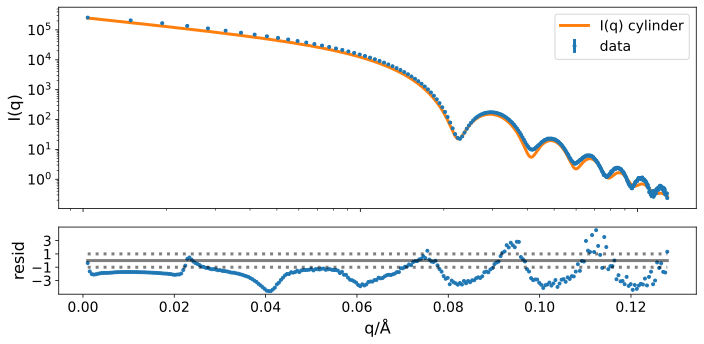

In [23]:
kernel = sasmodels.core.load_model("cylinder")

params = {
    "radius": 170,
    "radius_pd_type": 'gaussian', #type of polydispersity function
    "radius_pd": 0.05, #polydispersity
    "radius_pd_n": 8, #number of steps in polydispersity
    "radius_pd_nsigma": 4, #number of steps in polydispersity
     "length":16000,
    "length_pd_type": 'gaussian', #type of polydispersity function
    "length_pd": 0.01, #polydispersity
    "length_pd_n": 20, #number of steps in polydispersity
    "length_pd_nsigma": 4, #number of steps in polydispersity
    "sld": sld_silver,
    "sld_solvent": sld_water,
    "background": 0.0,
    "scale": 2e-3
}

model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

plt.figure(figsize=(10,5))

experiment.plot()

### Explanation of the polydispersity parameters

The polydispersity is set using a special set of \*\_pd\_\* parameters:
* `*_pd*` is the width of the polydispersity and the exact definition will depend on the type of distribution specified; in this cause of a 'gaussian` distribution, it is defined as as $\frac{\sigma}{x_{mean}}$
* `*_pd_type*` defines the type of polydispersity distribution used
* `*_pd_n` corresponds to the the number of points in the distribution used by the calculation (Npts in the image below)
* `*_pd_nsigma` sets the range of the distribution sampled (Nsigmas in the image below)

For example, radius polydispersity could be defined by specifying **all four** of the pd parameters. With the default values, this would look like:
* `radius_pd = 0`
* `radius_pd_type = 'gaussian'`
* `radius_pd_n = 35`
* `radius_pd_nsigma = 3`

The available polydispersity distributions are defined in the SasView [documentation](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html) but we can access them directly through the sasmodels `weights` module.

The 'gaussian' distribution is claculed by:

$$
f(x) = \frac{1}{Norm}\exp\left(-\frac{(x-x_{mean})^2}{2\sigma^2}\right)
$$

<img src=https://www.sasview.org/docs/_images/pd_gaussian.jpg>

*Image source: https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html*


## fiting the data

* choice of the initial values for parameters
* choice of the fiting parameters with their fiting range

step 1 cost 5.525(21)
                                  length .|........      16000 in [15000, 20000]
                               length_pd |.........       0.01 in [0.01, 0.3]
                                  radius ....|.....        170 in [150, 190]
                               radius_pd ....|.....       0.05 in [0.01, 0.1]
                                   scale .|........      0.002 in [0.001, 0.01]
step 2 cost 2.964(21)
                                  length .|........    15736.6 in [15000, 20000]
                               length_pd |.........  0.0356008 in [0.01, 0.3]
                                  radius .....|....    171.863 in [150, 190]
                               radius_pd ....|.....  0.0470333 in [0.01, 0.1]
                                   scale .|........ 0.00238564 in [0.001, 0.01]
step 3 cost 2.862(21)
                                  length .|........    15780.7 in [15000, 20000]
                               length_pd .|........  0.0456293 in

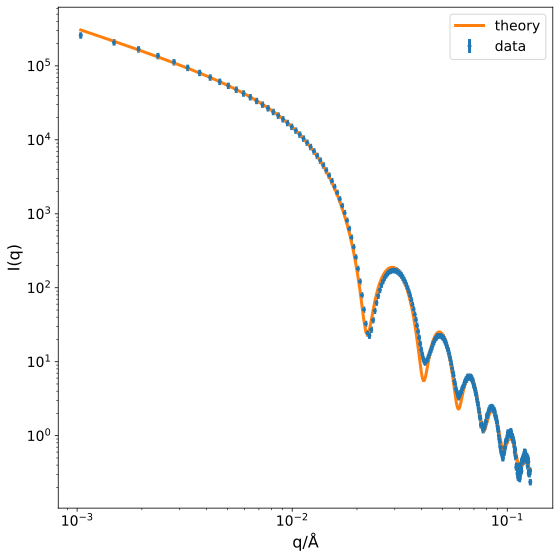

In [24]:
params = {
    "radius": 170,
    "radius_pd_type": 'gaussian', #type of polydispersity function
    "radius_pd": 0.05, #polydispersity
    "radius_pd_n": 8, #number of steps in polydispersity
    "radius_pd_nsigma": 4, #number of steps in polydispersity
     "length":16000,
    "length_pd_type": 'gaussian', #type of polydispersity function
    "length_pd": 0.01, #polydispersity
    "length_pd_n": 20, #number of steps in polydispersity
    "length_pd_nsigma": 4, #number of steps in polydispersity
    "sld": sld_silver,
    "sld_solvent": sld_water,
    "background": 0.0,
    "scale": 2e-3
}

model = sasmodels.bumps_model.Model(model=kernel, **params)

#list of the fiting parameters with their fiting range
model.scale.range(1e-3, 1e-2)
#model.background.range(0.0000000002,0.2)
model.radius.range(150, 190)
model.radius_pd.range(0.01,0.1)
model.length.range(15000, 20000)
model.length_pd.range(0.01,0.3)


experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=10, 
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
#problem.plot()
print(problem.summarize())
print(model.state())
print(problem.summarize())
print(problem.chisq())
sasmodels.data.plot_theory(data,experiment.Iq_calc)

The current value of all parameters can always be called using `model.state()`:

In [13]:
print(model.state())
print(problem.summarize())
print(problem.chisq())

{'scale': 0.002589176956055629, 'background': 0.0, 'sld': 77.9, 'sld_solvent': 9.47, 'radius': 170.86125293347376, 'radius_pd': 0.04793520248417013, 'radius_pd_n': 8.0, 'radius_pd_nsigma': 4.0, 'length': 15020.589347963165, 'length_pd': 0.09862203508003678, 'length_pd_n': 20.0, 'length_pd_nsigma': 4.0, 'theta': 60.0, 'theta_pd': 0.0, 'theta_pd_n': 35.0, 'theta_pd_nsigma': 3.0, 'phi': 60.0, 'phi_pd': 0.0, 'phi_pd_n': 35.0, 'phi_pd_nsigma': 3.0, 'up_frac_i': 0.0, 'up_frac_f': 0.0, 'up_theta': 90.0, 'up_phi': 0.0, 'sld_M0': 0.0, 'sld_mtheta': 0.0, 'sld_mphi': 0.0, 'sld_solvent_M0': 0.0, 'sld_solvent_mtheta': 0.0, 'sld_solvent_mphi': 0.0, 'radius_pd_type': 'gaussian', 'length_pd_type': 'gaussian', 'theta_pd_type': 'gaussian', 'phi_pd_type': 'gaussian'}
                                  length |.........    15020.6 in [15000, 20000]
                               length_pd ...|......   0.098622 in [0.01, 0.3]
                                  radius .....|....    170.861 in [150, 190]
     

* store the fited values in R_fit and L_fit

In [25]:
# value of R after fiting
R_fit=model.radius.value

# value of LR after fiting
L_fit=model.length.value

In [26]:
scale_fit=model.scale.value
print(scale_fit)

0.002414373243416016


In [27]:
density_Ag=10.49 # density in g/cm^3
M_Ag=107.89 # molar mass in g/mol

volume fraction and concentrations


In [29]:
volume_fraction=scale_fit
print("volume_fraction = ",volume_fraction)

density=density_Ag

mass_fraction=volume_fraction*density
print("mass_fraction = ",mass_fraction)

concentration_mM=1e6*volume_fraction*density/M_Ag
print("concentration in mM = ",concentration_mM)

volume_fraction =  0.002414373243416016
mass_fraction =  0.025326775323434008
concentration in mM =  234.7462723462231


#### Save the fited curve in a file
* `_fit` is added at the end of filename

In [30]:
fitfilename=filename[:-4]+"_fit.dat" # fit 

with open(fitfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(fitfilename, "a") as fa:
    for i in range(0,number_of_data_new-1):
        line_to_write=str(data.x[i])+"\t"+str(experiment.Iq_calc[i])+"\n"
        fa.write(line_to_write)

In [ ]:
results.x

array([2.00000000e-10, 1.90751811e+04, 3.99161117e-01, 1.70871316e+02,
       4.87025493e-02, 7.80408413e-05])

In [ ]:
results.dx

array([8.83257370e-04, 2.30696351e+02, 1.87909912e-02, 1.13394542e-01,
       6.05062287e-04, 5.93726426e-07])

### final plot
* use this one for a nice .svg output

2.8569503392104423


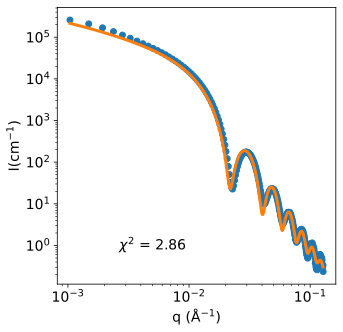

In [31]:
data_final = np.loadtxt(newfilename, skiprows=3)

fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)',fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)',fontsize=14)
plt.text(0.005,0.8,r'$\chi^2$ = '+f"{problem.chisq():.2f}",fontsize=14,horizontalalignment='center')
print(problem.chisq())
